# Fit VB + SB2 orbit using python version of Gail's code

based on /nfs/morgan/users/lester/Research/Programs/CHARA/orbitcode/katie_fit_orbit_vbsb2_ell.pro


In [1]:
import numpy as np
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from orbitcode import *
plt.style.use('katie') 
#from os import getcwd
np.set_printoptions(precision=2,linewidth=np.nan)
np.set_printoptions(suppress=True)
from astropy.time import Time


## Read in observations

In [3]:
# read in data sets
star = 'HD 89822'
print(star)


# Read in VB data file
# HJD, SEP, dSEP, PA, dPA
print('Reading in observations...')

# VB data
#  rho theta elliptical error bars
vb_file = 'vb_el_data.txt'
#tvb, sep, pa, emajor, eminor, eangle = np.loadtxt(vbfile, delimiter=' ', unpack=True)
tab  = ascii.read(vb_file,  data_start=0)
tvb  = np.array(tab['col1'])
theta    = np.array(tab['col2'])
rho      = np.array(tab['col3'])
dmajor   = np.array(tab['col4']) * np.sqrt(0.84707)
dminor   = np.array(tab['col5']) * np.sqrt(0.84707)
theta_err= np.array(tab['col6']) 

x = rho * np.sin(theta*np.pi/180.)   # CAREFUL. PA is measured FROM +Y axis so RA=sin(theta)
y = rho * np.cos(theta*np.pi/180.)



# Read in SB1 data file
# MJD, RV1, ERV1, RV2, ERV2
sb_file = 'sb2_data.txt'
#tsb, rv1, erv1, rv2, erv2 = np.loadtxt(sb_file, delimiter=' ', unpack=True)
tab  = ascii.read(sb_file,  data_start=0)
tsb = np.array(tab['col1'])
rv1   = np.array(tab['col2'])
erv1  = np.array(tab['col3']) * np.sqrt(0.84707)
rv2   = np.array(tab['col4'])
erv2  = np.array(tab['col5']) * np.sqrt(0.84707)

                                                  
print('  ', len(tvb), ' VB data points')
print('  ', len(tsb), ' SB data points')


# convert bessel to JD
#tvb2 = np.array(Time(tvb, format='byear', scale='utc').mjd)
#tsb = np.array(Time(tsb2, format='jd', scale='utc').byear)  # bessel




HD 89822
Reading in observations...
   11  VB data points
   66  SB data points


## Set guess orbital parameters

In [4]:
# initial guess orbital parameters
# period (days)
p = 11.5791             

# time of periastron (MJD)
t0 = 57756.168        

# eccentricity
e = 0.2            

# angluar semimajor axis (mas)
alpha = 2         

# inclination (deg)
inc = 141          

# longitude of ascending node of primary? (deg)
bigw = 130+180          

# argument of periastron of primary (deg)
w = 175                

# velocity semiamplitude primary (km/s)
K1 = 30            

# velocity semiamplitude secondary (km/s)
K2 = 60            

# systemic velocity (km/s)
V0 = 0        


# make parameter array
param = np.array([p, t0, e, alpha, inc, bigw, w, K1, K2, V0] )    

# choose which ones to fit for...  0=fixed, 1=vary
parfit= [1,  1,  1,   1,  1,   1,    1, 1,  1,  1]     


## Fit for VB+SB2 orbit!

In [5]:
# RUN FIT
EL, ELerr, chi2red_all, chi2red_vb, chi2red_sb = fit_orbit_vbsb2_ell(tvb, theta, rho, dmajor, dminor, theta_err, tsb, rv1, erv1, rv2, erv2, param, parfit)

#    El_vb = np.array([period,Tperi,ecc,major,inc,W_cap,w_low])
#    El_sb2 = np.array([period,Tperi,ecc,k1,k2,w_low,Vsys])
EL_vb = np.copy(EL[0:7])
EL_sb2 = np.append(np.copy(EL[0:3]), np.copy(EL[7:9]))
EL_sb2 = np.append(EL_sb2, np.copy(EL[6]))
EL_sb2 = np.append(EL_sb2, np.copy(EL[9]))

print(chi2red_all, chi2red_vb, chi2red_sb )
print('')

elLabel = ['P','T','e','a(mas)','i','Omega_B','omega_A','K1(km/s)','K2(km/s)','Vsys']
print("Best fit:")
for i in range(0, 1):
    print('%10s %11.5f %10.5f' % (elLabel[i], EL[i], ELerr[i]))
for i in range(1, 4):
    print('%10s %10.4f %10.4f' % (elLabel[i], EL[i], ELerr[i]))
for i in range(4, 7):
    print('%10s %10.4f %10.4f' % (elLabel[i], EL[i]* 180/np.pi, ELerr[i]* 180/np.pi))
for i in range(7, 10):
    print('%10s %10.4f %10.4f' % (elLabel[i], EL[i], ELerr[i]))
    

  Plotting initial guess...

  Continue? [y] y
  Running LM fit...

313.2573087261325
1 [   11.58 57756.14     0.31     1.58     2.5      5.47     3.07    37.68    61.61    -2.31] 3719.68171389254
313.5563977642808
2 [   11.58 57756.17     0.29     1.63     2.46     5.47     3.08    38.16    62.09    -2.24] 145.24035643398392
313.5668010051961
3 [   11.58 57756.17     0.29     1.63     2.46     5.47     3.08    38.17    62.11    -2.24] 144.00109214600403
313.56680951418144
4 [   11.58 57756.17     0.29     1.63     2.46     5.47     3.08    38.17    62.11    -2.24] 144.0010809453796

  reduced chi2 =  1.0000075065651362
1.0000075065651362 1.0189715107336716 1.0297320662749962

Best fit:
         P    11.57911    0.00001
         T 57756.1683     0.0048
         e     0.2943     0.0008
    a(mas)     1.6346     0.0013
         i   141.0413     1.2314
   Omega_B   313.5668     0.1383
   omega_A   176.5042     0.1849
  K1(km/s)    38.1677     0.0392
  K2(km/s)    62.1131     0.0849
      

### IDL answers
```
{Parameter}           {HD 89822}  	                
P (days)	          11.579113  0.000010	
T (HJD-2400000)    57756.168     0.005   	
e			           0.2943    0.0009  	
\alpha (mas)	       1.634     0.001   	
i (deg)		         141.87      0.97    	
\Omega (deg)	     133.49      0.13    	
\omega_1 (deg)	     176.50      0.20    	
K_1 (km s^{-1})       38.17      0.04    	
K_2 (km s^{-1})       62.11      0.09    	
\gamma (km s^{-1})	  -2.24      0.03    	
```

In [6]:
rho_mod, theta_mod = calc_vbfit(EL_vb, tvb, flagwa=1)
xmod = rho_mod * np.sin(theta_mod)    # CAREFUL. PA is measured FROM +Y axis so RA=sin(theta)
ymod = rho_mod * np.cos(theta_mod)

print(rho, theta*np.pi/180.)
print(rho_mod, theta_mod)


[1.88 1.   1.13 1.21 1.31 1.39 1.21 1.06 1.09 2.07 2.11] [4.92 2.91 2.13 3.97 0.4  4.53 3.92 2.98 2.02 5.63 5.58]
[1.86 1.11 1.15 1.18 1.33 1.44 1.15 1.09 1.15 2.05 2.11] [5.03 2.9  2.07 4.03 0.38 4.54 3.92 3.01 2.09 5.71 5.58]


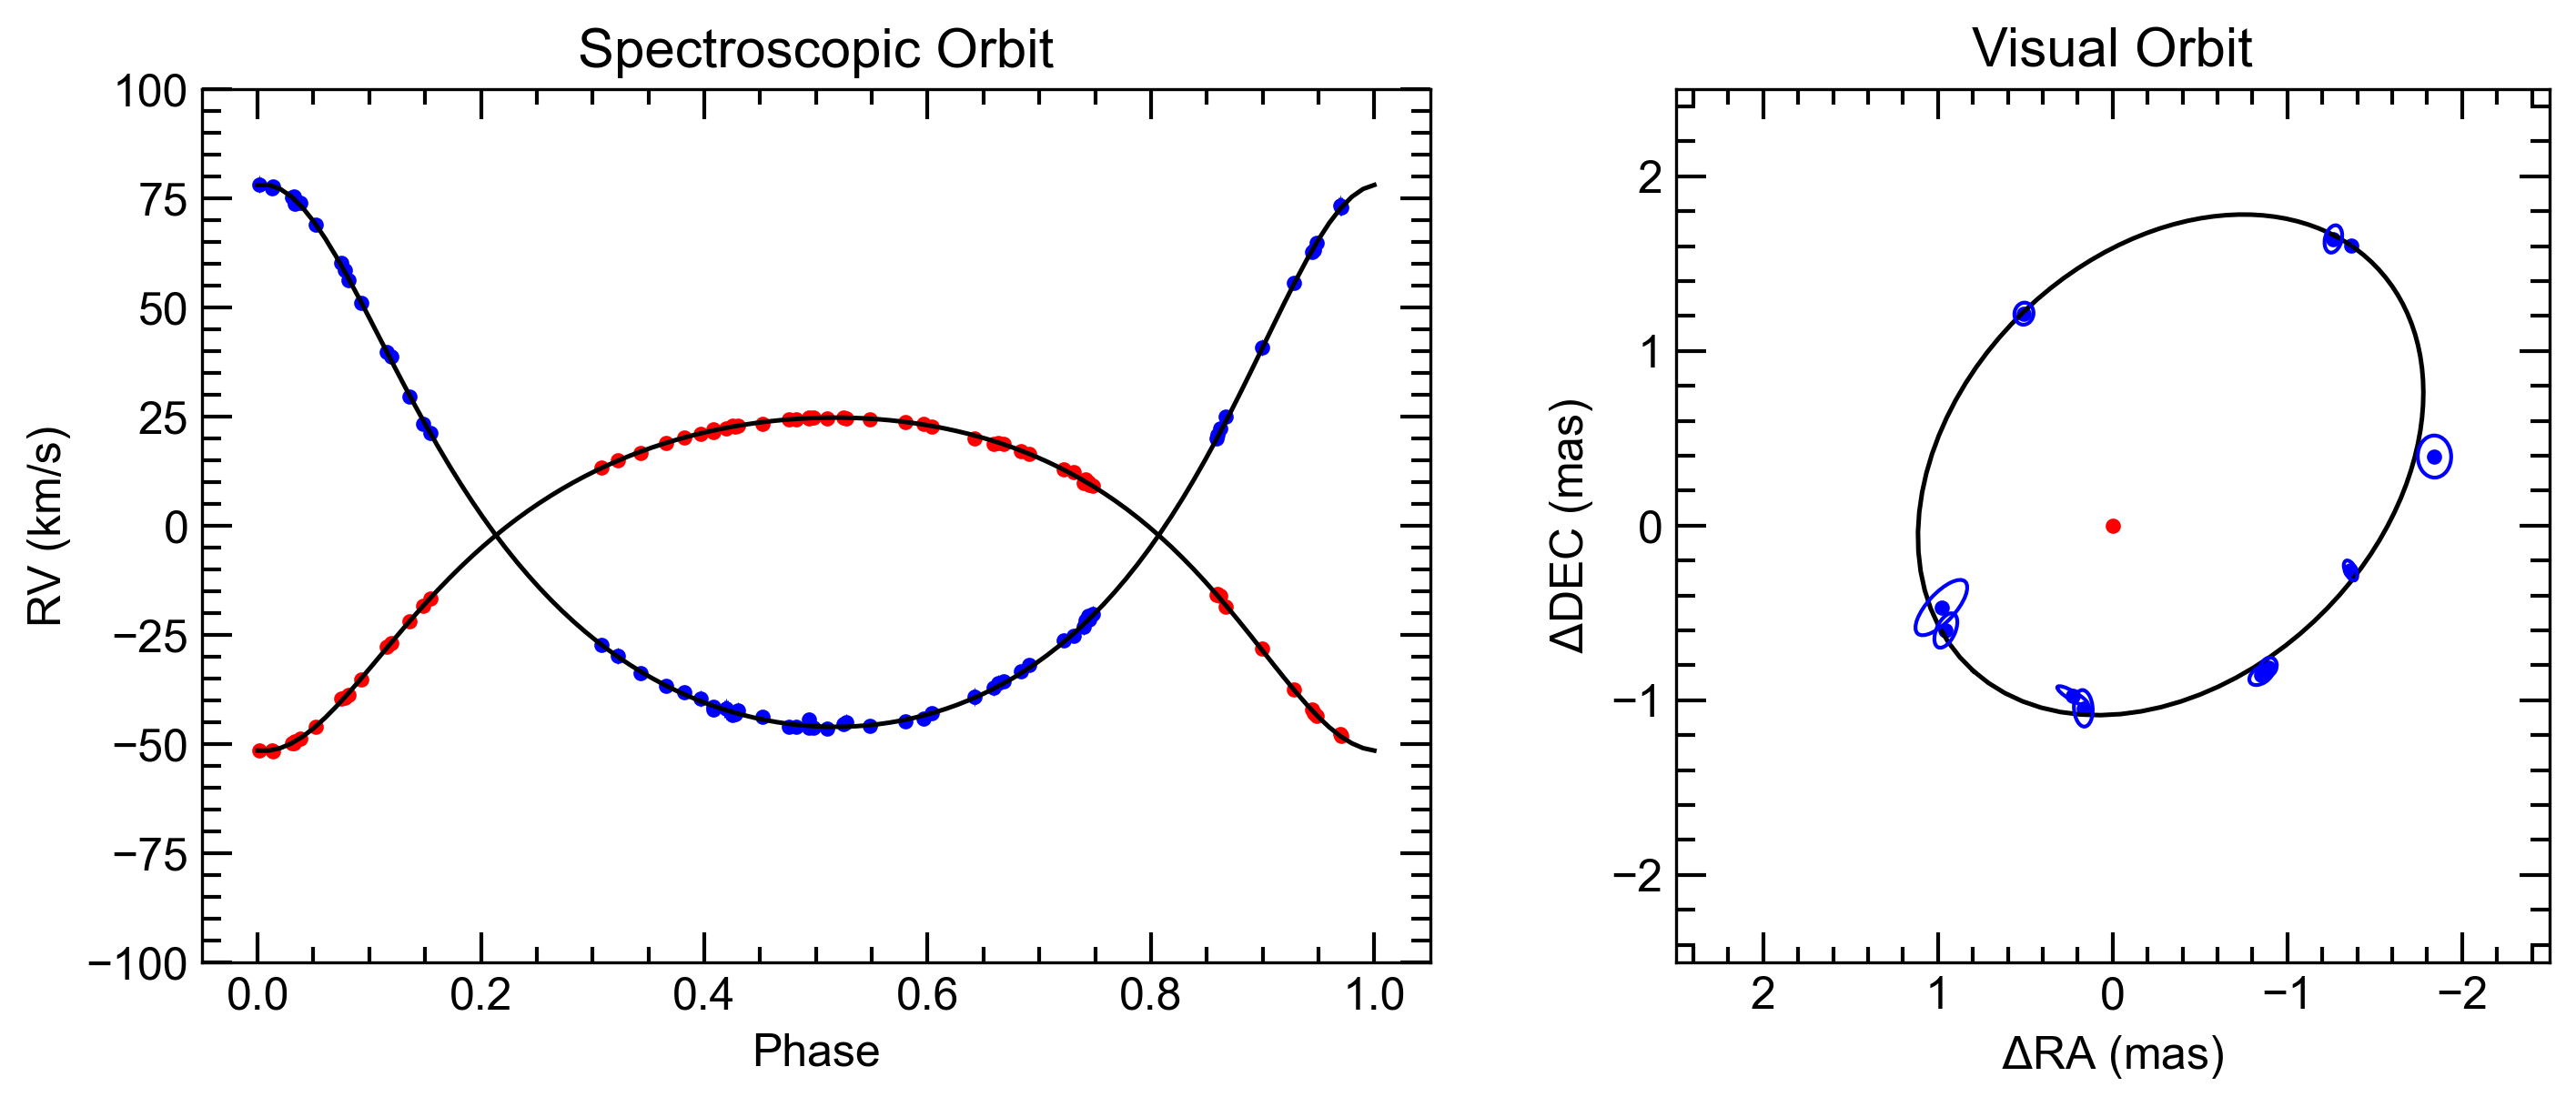

In [7]:
# PLOT RESULTS

x = rho * np.sin(theta*np.pi/180.)   # CAREFUL. PA is measured FROM +Y axis so RA=sin(theta)
y = rho * np.cos(theta*np.pi/180.)

tmod = np.linspace(EL[1], EL[1]+EL[0]-0.0001, 100)

rho_mod, theta_mod = calc_vbfit(EL_vb, tmod, flagwa=1)
xmod = rho_mod * np.sin(theta_mod)    # CAREFUL. PA is measured FROM +Y axis so RA=sin(theta)
ymod = rho_mod * np.cos(theta_mod)

phobs = (tsb - EL[1]) / EL[0] % 1
phmod = (tmod - EL[1]) / EL[0] % 1
rvmod1, rvmod2 = calc_sb2fit(EL_sb2, tmod)


fig = plt.figure(figsize=(10,4))

ax1 = fig.add_axes([0.57, 0.10, 0.40, 0.80])   
plt.plot([0], [0], marker='o', color='red', ms=3)
plt.plot(x, y, linestyle=' ', color='blue', marker='o', ms=3) 

for i in range(0, len(tvb)):
    #  width = total major axis,  height = total minor axis,  angle = deg ccw
    e1 = Ellipse(xy=(x[i], y[i]), width=dmajor[i]*2, height=dminor[i]*2, angle=90-theta_err[i]*180/np.pi, fill=False, color='blue', zorder=5)
    ax1.add_patch(e1)

xr = 2.5
plt.xlim(xr, -1*xr)
plt.ylim(-1*xr, xr)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('$\\Delta$RA (mas)' )
plt.ylabel('$\\Delta$DEC (mas)')
plt.title('Visual Orbit')

ax2 = fig.add_axes([0.07, 0.10, 0.45, 0.80])  
plt.errorbar(phobs, rv1, erv1, linestyle=' ', color='red', capsize=0.1)
plt.plot(phobs, rv1, marker='o', color='red', linestyle=' ',  ms=3)
plt.errorbar(phobs, rv2, erv2, linestyle=' ', color='blue', capsize=0.1)
plt.plot(phobs, rv2, marker='o', color='blue', linestyle=' ',  ms=3)
plt.xlabel('Phase')
plt.ylabel('RV (km/s)')
plt.title('Spectroscopic Orbit')
plt.ylim(-100, 100)

ax1.plot(xmod, ymod, color='black')
ax2.plot(phmod, rvmod1, color='black')
ax2.plot(phmod, rvmod2, color='black')

plt.savefig('vbsb2.png', dpi=400, bbox_inches='tight')
plt.show()
plt.close()

## Calculate mass and distance

In [8]:
# Calculate absolute parameters
p      =  EL[0]
ep     =  ELerr[0]
t0     =  EL[1]
et0    =  ELerr[1]
e      =  EL[2]
ee     =  ELerr[2] 
alpha  =  EL[3] # angular semimajor axis
ealpha =  ELerr[3]
ir     =  EL[4] # rad
eir    =  ELerr[4]
k1     =  EL[7]
ek1    =  ELerr[7]
k2     =  EL[8]
ek2    =  ELerr[8]

# IDL answers
#p, ep = 11.579113 , 0.000010
#e, ee= 0.2943  ,  0.0009 
#i, ei = 141.87,  0.97 
#ir = i * np.pi/180.
#eir = ei * np.pi/180.
#alpha, ealpha = 1.634 , 0.001 
#k1, ek1 = 38.17  , 0.04 
#k2, ek2 = 62.11  , 0.09



# PROJECTED RESULTS FROM SPECTROSCOPY
# mass ratio
q = k1/k2   # m2/m1
eqq = q*np.sqrt((ek1/k1)**2+(ek2/k2)**2)

# a * sin i  (physical semimajor axis) coeff from Torres 2010
asin = (1.976682e-2)*(1.-e**2)**0.5*p*(k1+k2) # Rsun
eas = asin*np.sqrt((ee*e/(1.-e**2))**2+(ek1**2+ek2**2)/(k1+k2)**2)

# M sin i    coeff from Torres 2010
m1s = 1.036149e-7*p*k2*(1.-e**2)**1.5*(k1+k2)**2 # Msun
m1err = (3.*e*ee/(1.-e**2))**2 + 4.*(ek1**2+ek2**2)/(k1+k2)**2+(ek2/k2)**2
em1s = m1s*np.sqrt(m1err)
em1s = m1s*np.sqrt( (3*ee/e)**2 + (2*ek1/k1)**2 + (2*ek2/k2)**2 + (ep/p)**2  )
m2s = 1.036149e-7*p*k1*(1.-e**2)**1.5*(k1+k2)**2 # Msun
m2err = (3.*e*ee/(1.-e**2))**2+4.*(ek1**2+ek2**2)/(k1+k2)**2+(ek1/k1)**2
em2s = m2s*np.sqrt(m2err)
em2s = m2s*np.sqrt( (3*ee/e)**2 + (2*ek1/k1)**2 + (2*ek2/k2)**2 + (ep/p)**2  )


# INLCINATION FROM INTERFEROMETRY
sini = abs(np.sin(ir))
esini = abs( np.sin(ir) - np.sin(ir+eir) )


# PHYSICAL UNITS
# semimajor axis in Rsun
a = asin/sini 
ea = a * np.sqrt((eas/asin)**2 + (esini/sini)**2)

# Masses in Msun
f2 = 1./sini**3
m1 = m1s*f2
em1 = np.sqrt(  (em1s/m1s)**2 + (3*esini/sini)**2  ) * m1
m2 = m2s*f2
em2 = np.sqrt(  (em2s/m2s)**2 + (3*esini/sini)**2  ) * m2

# Distance in pc
Rsun = 6.957e8 # m  Torres10
pc = 3.086e16 # m
d = (a*Rsun/pc) / (alpha/1000./60./60./180*np.pi) # pc
ed = d * np.sqrt( (ea/a)**2 + (ealpha/alpha)**2  )


print('%s %5.3f  %6.3f' % ('M1 (Msun) ', m1, em1))
print('%s %5.3f  %6.3f' % ('M2 (Msun) ', m2, em2))
print('%s %5.3f  %5.3f' % ('a (Rsun)  ', a, ea  ))
print('%s %5.3f  %5.3f' % ('d (pc)    ', d, ed  ))

M1 (Msun)  2.632   0.213
M2 (Msun)  1.617   0.131
a (Rsun)   34.888  0.936
d (pc)     99.248  2.664
